In [1]:
# Nuestro proyecto trabaja en 3 niveles
# y cada uno necesita reglas distintas:

# 1. Episodio (fila) → una internación en un hospital
# 2. Transición (arista) → movimiento entre hospitales
# 3. Paciente (trayectoria completa) → historia total


# en este archivo:
# BASE 1 — df_base_limpia (episodios)
# - Objetivo: Tener todas las internaciones válidas, sin romper historias

# - ERROR en tu enfoque actual: Estás filtrando pacientes enteros (pacientes_final_ok), cuando acá deberías: NO eliminar pacientes todavía

# - Qué limpiar acá (solo cosas “objetivamente malas”)

#             - filas con:

#             fechas inválidas (fecha_ingreso > fecha_egreso)
#             hospitales missing
#             edad absurda (ej: <0 o >120)
#             motivos claramente basura (error, quizás nan dependiendo contexto)

#             - estandarización:

#             nombres hospitales
#             fechas
#             motivos (lowercase, strip)

#                     PERO:
#                     ❌ NO usar desenlace todavía
#                     ❌ NO eliminar pacientes completos
#                     ❌ NO usar prioridad clínica todavía

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import ast
import pandas as pd
import numpy as np
from src.config import *

In [3]:
# 1. CARGA Y RENOMBRE COMPLETO (Recuperado de tu código original)
# ==============================================================================
df_raw = pd.read_excel("../data/pacientes.xlsx")
hospitales = pd.read_csv("../data/hospitales_coordenadas.csv")

dict_comp = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))
hospitales['color_rgb'] = hospitales['color'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df_base = df_raw.rename(columns={
    'Id Hospital': 'hospital_id', 'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id', 'Fecha inicio': 'fecha_ingreso', 'Fecha egreso': 'fecha_egreso',
    'Estado al ingreso': 'estado_ingreso', 'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo', 'Último tipo': 'tipo_ultimo',
    'Sexo': 'sexo', 'Edad': 'edad', 'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social', 'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria', 'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis', '1º dosis': 'fecha_dosis_1', '2º dosis': 'fecha_dosis_2',
    'Buscado en el ministerio': 'validado_ministerio', 'Obra social': 'obra_social',
    'Asistencia Respiratoria Mecánica': 'requiere_arm', 'Motivo': 'motivo_egreso',
    'Operación': 'operacion', 'Última actualización': 'fecha_ultima_actualizacion',
    'Pasó por Críticas': 'paso_criticas', 'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

df_base['hospital_origen'] = df_base['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
}).str.strip()


df_base['fecha_ingreso'] = pd.to_datetime(df_base['fecha_ingreso'], errors='coerce')
df_base['fecha_egreso'] = pd.to_datetime(df_base['fecha_egreso'], errors='coerce')
df_base['edad'] = pd.to_numeric(df_base['edad'], errors='coerce')
df_base['dias_en_nodo'] = (
    (df_base['fecha_egreso'] - df_base['fecha_ingreso'])
    .dt.days
)

df_base = df_base.sort_values(['paciente_id', 'fecha_ingreso'])

In [ ]:
# 2. FLAGS DE VALIDACIÓN (nivel episodio)
# ==============================================================================

# --- validez mínima (estructura del episodio)
df_base['valido_core'] = (
    df_base['paciente_id'].notna() &
    df_base['hospital_origen'].notna() &
    df_base['fecha_egreso'].notna()
)

# --- consistencia de fechas
df_base['fechas_validas'] = (
    (df_base['fecha_ingreso'] <= df_base['fecha_egreso'])
    # &
    # (df_base['fecha_egreso'] - df_base['fecha_ingreso'] >= pd.Timedelta(minutes=5))
)

In [5]:
# 3. FLAGS DE CALIDAD (NO filtran, solo informan)
# ==============================================================================

# edad fuera de rango razonable
df_base['edad_rara'] = (
    (df_base['edad'] < 0) | (df_base['edad'] > 110)
)

# duración negativa o muy larga
df_base['duracion_negativa'] = df_base['dias_en_nodo'] < 0
df_base['duracion_larga'] = df_base['dias_en_nodo'] > 60  # ajustable

# hospital faltante o vacío
df_base['hospital_raro'] = df_base['hospital_origen'].isna() | (df_base['hospital_origen'] == '')

In [6]:
# 4. LIMPIEZA DE motivo_egreso (sin eliminar todavía)
# ==============================================================================

# normalizar texto
df_base['motivo_egreso_clean'] = (
    df_base['motivo_egreso']
    .astype(str)
    .str.lower()
    .str.strip()
)

# flag administrativo inválido
df_base['egreso_admin_invalido'] = df_base['motivo_egreso_clean'].str.contains(
    'anulado|error|duplicado', case=False, na=False
)

# clasificación simple (puede crecer después)
def clasificar_egreso(x):
    if pd.isna(x):
        return 'desconocido'
    x = str(x).lower()
    if 'muerte' in x:
        return 'muerte'
    elif 'alta-domiciliaria' in x:
        return 'alta'
    elif 'traslado-extra-sanitario' in x:
        return 'hotel'
    elif 'traslado-otro' in x:
        return 'hospital-externo'
    elif 'traslado-hospital-de-la-red' in x:
        return 'traslado'
    elif 'anulado' in x or 'otro' in x:
        return 'administrativo'
    elif 'traslado-extra-sanitario' in x:
        return 'hotel'
    else:
        return 'administrativo'

df_base['tipo_egreso'] = df_base['motivo_egreso'].apply(clasificar_egreso)

In [7]:
# 5. CONSTRUCCIÓN DE BASE LIMPIA (mínimamente filtrada)
# ==============================================================================

df_base_limpia = df_base[
    df_base['valido_core'] &
    df_base['fechas_validas']
].copy()

In [8]:
# 6. CHECKS BÁSICOS (para que mires calidad sin romper nada)
# ==============================================================================

print("Total episodios:", len(df_base))
print("Episodios válidos:", len(df_base_limpia))

print("\n% edad rara:", df_base_limpia['edad_rara'].mean())
print("% sin fecha egreso:", df_base_limpia['fecha_egreso'].isna().mean())
print("% egreso administrativo:", df_base_limpia['egreso_admin_invalido'].mean())

print("\nDuración (días) resumen:")
print(df_base_limpia['dias_en_nodo'].describe())

print("\nTop hospitales:")
print(df_base_limpia['hospital_origen'].value_counts().head(10))

Total episodios: 29697
Episodios válidos: 24953

% edad rara: 0.004368212239009337
% sin fecha egreso: 0.0
% egreso administrativo: 0.022842944736103876

Duración (días) resumen:
count    24953.000000
mean         9.779265
std         18.124005
min          0.000000
25%          2.000000
50%          5.000000
75%         11.000000
max        553.000000
Name: dias_en_nodo, dtype: float64

Top hospitales:
hospital_origen
Mi Pueblo                      4267
Oñativia                       3555
UPA 5 - AB                     3019
Lucio Meléndez                 2788
Oller                          1658
Módulo Hospitalario 11 - FV    1604
UPA 11 - FV                    1541
Evita Pueblo                   1461
El Cruce                       1321
Módulo Hospitalario 10 - QU    1178
Name: count, dtype: int64


In [22]:
# esta base responde
# “qué internaciones existieron realmente”
# (o deberian. Para mi hay repetidos que no se como sacar)
    # # faltaria:
    # - resolver duplicados
    # - resolver superposiciones
    # - consistencia longitudinal por paciente

In [24]:
df_base_limpia.to_excel("../data/final_data/df_base_limpia.xlsx", index=False)
# df_base_limpia.to_parquet("../data/final_data/df_base_limpia.parquet", index=False)

### Extra: busqueda de errores o casos raros

In [9]:
# pacientes que estuvieron la mayor cantidad de tiempo internados
# me llamo la atencion 500 dias asi que reviso esto..
cols = [
    'paciente_id',
    'hospital_origen',
    'fecha_ingreso',
    'fecha_egreso',
    'dias_en_nodo',
    'motivo_egreso',
    'tipo_egreso'
]

df_base_limpia.loc[
    df_base_limpia['dias_en_nodo'] == df_base_limpia['dias_en_nodo'].max(),
    cols
]

df_base_limpia.nlargest(10, 'dias_en_nodo')[cols]

(df_base_limpia['dias_en_nodo'] > 100).mean()

np.float64(0.00625175329619685)

In [10]:
# pacientes que estuvieron la mayor cantidad de tiempo internados
df_base_limpia.nsmallest(10, 'dias_en_nodo')[cols]
(df_base_limpia['dias_en_nodo'] < 1).mean()

np.float64(0.09449765559251393)

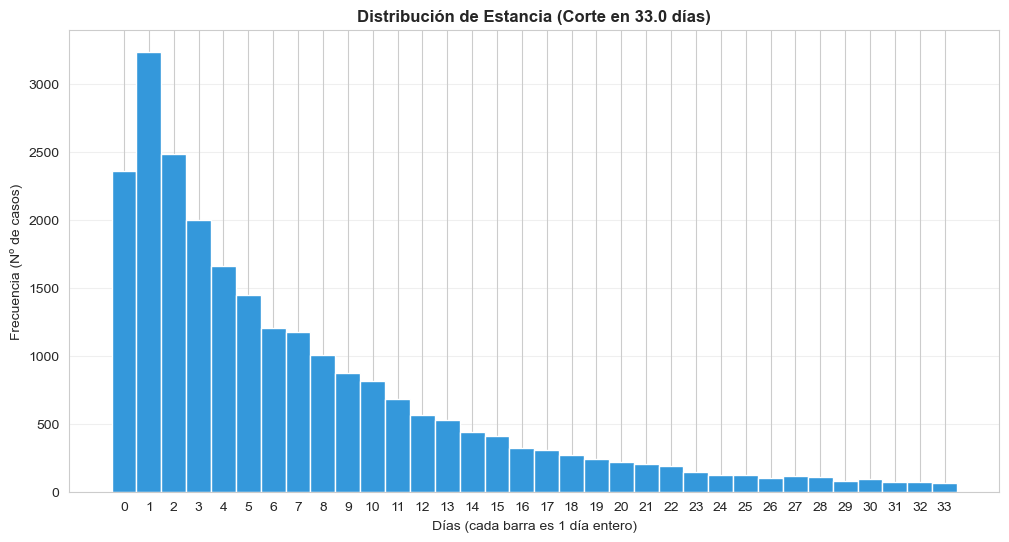

El gráfico muestra el 95% de los datos. El valor máximo mostrado es 33 días.


In [ ]:
# distribución de duración
import matplotlib.pyplot as plt

# 1. Calculamos el límite del percentil (ej: 95%)
# Esto ignora el 5% de los casos con estancias extremadamente largas
limite_outliers = df_base_limpia['dias_en_nodo'].quantile(0.95)

# 2. Filtramos los datos
df_filtrado = df_base_limpia[df_base_limpia['dias_en_nodo'] <= limite_outliers]

# 3. Configuramos los bins para que cada uno sea un entero
valor_max = int(df_filtrado['dias_en_nodo'].max())
# Usamos np.arange para crear cortes cada 0.5 para que el entero quede en el centro
bins = np.arange(0, valor_max + 2) - 0.5

# 4. Graficamos
plt.figure(figsize=(12, 6))
plt.hist(df_filtrado['dias_en_nodo'], bins=bins, edgecolor='white', color='#3498db')

# Forzamos a que el eje X muestre los números de 1 en 1
plt.xticks(range(0, valor_max + 1))

plt.title(f'Distribución de Estancia (Corte en {limite_outliers:.1f} días)')
plt.xlabel('Días (cada barra es 1 día entero)')
plt.ylabel('Frecuencia (Nº de casos)')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"El gráfico muestra el 95% de los datos. El valor máximo mostrado es {valor_max} días.")

In [12]:
# 2 mins de diferencia egreso - ingreso

# Calcular la diferencia exacta en minutos
# .total_seconds() / 60 nos da la precisión que buscas
duracion_minutos = (df_base_limpia['fecha_egreso'] - df_base_limpia['fecha_ingreso']).dt.total_seconds() / 60

# Filtrar los que duran 2 minutos o menos (incluye negativos si los hay)
errores_tiempo = df_base_limpia[duracion_minutos <= 2]

# Resultados
total_errores = len(errores_tiempo)
porcentaje_errores = (total_errores / len(df_base_limpia)) * 100

print(f"Detectados {total_errores} registros con duración <= 2 minutos.")
print(f"Representan el {porcentaje_errores:.2f}% del total de la base.")

# Ver una muestra de esos errores para confirmar
print("\nMuestra de posibles errores:")
print(errores_tiempo[['fecha_ingreso', 'fecha_egreso', 'dias_en_nodo']].head())

Detectados 2357 registros con duración <= 2 minutos.
Representan el 9.45% del total de la base.

Muestra de posibles errores:
            fecha_ingreso        fecha_egreso  dias_en_nodo
8     2020-05-21 12:11:05 2020-05-21 12:11:05           0.0
16    2020-05-29 12:11:05 2020-05-29 12:11:05           0.0
24    2020-06-06 12:11:05 2020-06-06 12:11:05           0.0
23788 2022-02-22 12:11:25 2022-02-22 12:11:25           0.0
22312 2020-09-10 12:11:25 2020-09-10 12:11:25           0.0


In [13]:
# pacientes con muchos episodios
df_base_limpia['paciente_id'].value_counts().head(10)

paciente_id
MF69    10
NV93     8
AB52     6
AO28     6
BH66     6
FG00     6
MO94     6
UV70     6
WN04     6
WR46     6
Name: count, dtype: int64

In [ ]:
# episodios que potencialmente son duplicados
df_base_limpia[
    df_base_limpia.duplicated(
        subset=['paciente_id', 'hospital_origen', 'fecha_ingreso'], ## obs, hay un problema grande con las fechas de ingreso.
        # Para mi se hacian en un momento dado del dia se actualizaban todas
        keep=False
    )
].sort_values(['paciente_id', 'fecha_ingreso']).head(10)

In [17]:
# hospitales con duracion de estadias mas altos
df_base_limpia.groupby('hospital_origen')['dias_en_nodo'].mean().sort_values(ascending=False).head(10)

hospital_origen
Módulo Hospitalario 8 - LZ     21.482143
Iriarte                        19.225282
El Cruce                       13.857684
Oñativia                       13.351617
Mi Pueblo                      12.846965
Lucio Meléndez                 11.314204
Módulo Hospitalario 10 - QU    10.653650
Módulo Hospitalario 11 - FV     9.905860
Evita Pueblo                    9.777550
Módulo Hospitalario 9 - AB      8.619349
Name: dias_en_nodo, dtype: float64

In [ ]:
# cuantos hay de cada tipo, para ver cuantos son administrativos
df_base_limpia['tipo_egreso'].value_counts(normalize=True)

tipo_egreso
alta                0.575762
administrativo      0.111049
muerte              0.107963
hospital-externo    0.100188
traslado            0.094738
hotel               0.010299
Name: proportion, dtype: float64

In [21]:
# columnas que NO podemos usar:
print(df_base_limpia.isna().mean().sort_values(ascending=False).head(10))

comorbilidades_pediatria    1.000000
requiere_arm                0.953352
fecha_dosis_2               0.894602
fecha_dosis_1               0.865708
cantidad_dosis              0.859496
validado_ministerio         0.839699
vacuna                      0.654510
obra_social                 0.620206
comorbilidades_covid        0.453252
riesgo_social               0.125195
dtype: float64
